# Named Entity Recognition: Token Classification

## 1. Introduction

**Named Entity Recognition (NER)** is a fundamental NLP task that identifies and classifies named entities in text into predefined categories such as person names, organizations, locations, and more.

### What we'll learn:
- What NER is and why it's important
- BIO tagging scheme for sequence labeling
- Rule-based and CRF baselines
- BiLSTM-CRF architecture from scratch
- BERT for token classification
- Proper evaluation metrics (entity-level F1)
- Handling subword tokenization alignment

### Real-world Applications:
- Information extraction from documents
- Question answering systems
- Content recommendation
- Medical record analysis
- Customer service automation

### Key Challenge:
Unlike simple classification where we assign one label per sentence, NER requires **token-level classification** where each word gets its own label. This means handling variable-length sequences and ensuring label consistency (e.g., I-PER can only follow B-PER or I-PER).

## 2. Setup

Import the libraries we'll need for NER.

In [ ]:


%load_ext autoreload
%autoreload 2

Set random seed for reproducibility.

In [ ]:
from aiml_notebooks import get_device, set_seed

In [2]:
set_seed(42)

Configure device (prefer CPU for transformer operations to avoid MPS issues).

In [3]:
device = get_device(prefer_cpu=True)
print(f"Using device: {device}")

Using CPU
Note: MPS is available but not used due to compatibility issues
To use MPS with CPU fallback, run: PYTORCH_ENABLE_MPS_FALLBACK=1 jupyter lab
Using device: cpu


## 3. Understanding NER and BIO Tagging

### 3.1 What is NER?

NER is a **token-level classification task** where we assign a label to each word in a sentence.

**Example**:
```
Text:   Barack Obama was born in Hawaii and worked in Chicago .
Labels: B-PER  I-PER  O    O    O  B-LOC  O   O      O  B-LOC   O
```

**Common Entity Types**:
- **PER**: Person names (Barack Obama, Marie Curie)
- **ORG**: Organizations (Google, United Nations)
- **LOC**: Locations (Paris, Mount Everest)
- **MISC**: Miscellaneous (Nobel Prize, French Revolution)

### 3.2 BIO Tagging Scheme

The **BIO scheme** (also called IOB) distinguishes between the beginning and inside of entities:

- **B-XXX**: Beginning of entity type XXX
- **I-XXX**: Inside (continuation) of entity type XXX  
- **O**: Outside any entity

**Why BIO instead of simple labels?**

Consider: "Apple and Google are tech companies"

Simple labeling:
```
Apple   -> ORG
and     -> O
Google  -> ORG
```

BIO labeling:
```
Apple   -> B-ORG
and     -> O
Google  -> B-ORG
```

This distinguishes consecutive entities of the same type! Without B/I tags, "Apple Google" would look like one entity.

Create a helper function to visualize BIO tagging.

In [4]:
def visualize_bio_tags(tokens, tags):
    """Display tokens with their BIO tags in a readable format."""
    print(f"{'Token':<15} {'BIO Tag':<10}")
    print("-" * 25)
    for token, tag in zip(tokens, tags):
        print(f"{token:<15} {tag:<10}")
    
    # Extract entities
    entities = []
    current_entity = []
    current_type = None
    
    for token, tag in zip(tokens, tags):
        if tag.startswith('B-'):
            if current_entity:
                entities.append((' '.join(current_entity), current_type))
            current_entity = [token]
            current_type = tag[2:]
        elif tag.startswith('I-') and current_entity:
            current_entity.append(token)
        else:
            if current_entity:
                entities.append((' '.join(current_entity), current_type))
            current_entity = []
            current_type = None
    
    if current_entity:
        entities.append((' '.join(current_entity), current_type))
    
    print("\nExtracted Entities:")
    for entity, etype in entities:
        print(f"  {entity:<20} [{etype}]")

# Example
tokens = ["Barack", "Obama", "was", "born", "in", "Hawaii", "and", "worked", "in", "Chicago", "."]
tags = ["B-PER", "I-PER", "O", "O", "O", "B-LOC", "O", "O", "O", "B-LOC", "O"]

visualize_bio_tags(tokens, tags)

Token           BIO Tag   
-------------------------
Barack          B-PER     
Obama           I-PER     
was             O         
born            O         
in              O         
Hawaii          B-LOC     
and             O         
worked          O         
in              O         
Chicago         B-LOC     
.               O         

Extracted Entities:
  Barack Obama         [PER]
  Hawaii               [LOC]
  Chicago              [LOC]


**Key Insight**: The BIO scheme allows us to:
1. Distinguish consecutive entities of the same type
2. Identify multi-word entities (I-XXX follows B-XXX)
3. Enforce valid label sequences (constraints used by CRF)

## 4. Creating a Synthetic NER Dataset

We'll create a synthetic dataset in CoNLL-2003 format for demonstration. In practice, you would use real datasets like CoNLL-2003, OntoNotes, or domain-specific annotated data.

Create synthetic NER training examples.

In [5]:
# Synthetic NER dataset
train_data = [
    # Format: (tokens, tags)
    (["Barack", "Obama", "was", "born", "in", "Hawaii", "."], 
     ["B-PER", "I-PER", "O", "O", "O", "B-LOC", "O"]),
    
    (["Google", "is", "headquartered", "in", "California", "."],
     ["B-ORG", "O", "O", "O", "B-LOC", "O"]),
    
    (["Marie", "Curie", "won", "the", "Nobel", "Prize", "."],
     ["B-PER", "I-PER", "O", "O", "B-MISC", "I-MISC", "O"]),
    
    (["Apple", "and", "Microsoft", "are", "tech", "companies", "."],
     ["B-ORG", "O", "B-ORG", "O", "O", "O", "O"]),
    
    (["The", "Eiffel", "Tower", "is", "in", "Paris", "."],
     ["O", "B-LOC", "I-LOC", "O", "O", "B-LOC", "O"]),
    
    (["Albert", "Einstein", "developed", "the", "theory", "of", "relativity", "."],
     ["B-PER", "I-PER", "O", "O", "O", "O", "O", "O"]),
    
    (["Amazon", "operates", "in", "Seattle", "."],
     ["B-ORG", "O", "O", "B-LOC", "O"]),
    
    (["The", "United", "Nations", "is", "based", "in", "New", "York", "."],
     ["O", "B-ORG", "I-ORG", "O", "O", "O", "B-LOC", "I-LOC", "O"]),
    
    (["Steve", "Jobs", "founded", "Apple", "."],
     ["B-PER", "I-PER", "O", "B-ORG", "O"]),
    
    (["London", "is", "the", "capital", "of", "England", "."],
     ["B-LOC", "O", "O", "O", "O", "B-LOC", "O"]),
    
    (["IBM", "and", "Intel", "competed", "in", "technology", "."],
     ["B-ORG", "O", "B-ORG", "O", "O", "O", "O"]),
    
    (["The", "World", "Cup", "was", "held", "in", "Brazil", "."],
     ["O", "B-MISC", "I-MISC", "O", "O", "O", "B-LOC", "O"]),
]

# Test data
test_data = [
    (["Bill", "Gates", "founded", "Microsoft", "."],
     ["B-PER", "I-PER", "O", "B-ORG", "O"]),
    
    (["Tesla", "is", "based", "in", "Austin", "."],
     ["B-ORG", "O", "O", "O", "B-LOC", "O"]),
    
    (["The", "Olympics", "were", "held", "in", "Tokyo", "."],
     ["O", "B-MISC", "O", "O", "O", "B-LOC", "O"]),
]

print(f"Training examples: {len(train_data)}")
print(f"Test examples: {len(test_data)}")
print("\nSample training example:")
visualize_bio_tags(train_data[0][0], train_data[0][1])

Training examples: 12
Test examples: 3

Sample training example:
Token           BIO Tag   
-------------------------
Barack          B-PER     
Obama           I-PER     
was             O         
born            O         
in              O         
Hawaii          B-LOC     
.               O         

Extracted Entities:
  Barack Obama         [PER]
  Hawaii               [LOC]


Build vocabulary and label mappings.

In [6]:
# Build vocabularies
all_tokens = []
all_tags = []

for tokens, tags in train_data:
    all_tokens.extend(tokens)
    all_tags.extend(tags)

# Word vocabulary
vocab = {"<PAD>": 0, "<UNK>": 1}
for token in set(all_tokens):
    if token not in vocab:
        vocab[token] = len(vocab)

# Tag vocabulary
tag_vocab = {"<PAD>": 0}
for tag in set(all_tags):
    if tag not in tag_vocab:
        tag_vocab[tag] = len(tag_vocab)

# Reverse mappings
idx2word = {v: k for k, v in vocab.items()}
idx2tag = {v: k for k, v in tag_vocab.items()}

print(f"Vocabulary size: {len(vocab)}")
print(f"Number of tag types: {len(tag_vocab)}")
print(f"\nTag vocabulary: {sorted([tag for tag in tag_vocab.keys() if tag != '<PAD>'])}")

Vocabulary size: 57
Number of tag types: 10

Tag vocabulary: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']


Create helper functions to encode/decode sequences.

In [7]:
def encode_sequence(tokens, tags, vocab, tag_vocab, max_len=20):
    """Encode tokens and tags to indices with padding."""
    # Encode tokens
    token_ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    tag_ids = [tag_vocab[tag] for tag in tags]
    
    # Pad or truncate
    if len(token_ids) < max_len:
        token_ids = token_ids + [vocab["<PAD>"]] * (max_len - len(token_ids))
        tag_ids = tag_ids + [tag_vocab["<PAD>"]] * (max_len - len(tag_ids))
    else:
        token_ids = token_ids[:max_len]
        tag_ids = tag_ids[:max_len]
    
    return token_ids, tag_ids

def decode_sequence(token_ids, tag_ids, idx2word, idx2tag):
    """Decode indices back to tokens and tags."""
    tokens = [idx2word[idx] for idx in token_ids if idx != 0]
    tags = [idx2tag[idx] for idx in tag_ids if idx != 0]
    return tokens, tags

# Test encoding/decoding
sample_tokens, sample_tags = train_data[0]
encoded_tokens, encoded_tags = encode_sequence(sample_tokens, sample_tags, vocab, tag_vocab)
decoded_tokens, decoded_tags = decode_sequence(encoded_tokens, encoded_tags, idx2word, idx2tag)

print("Original:")
print(f"  Tokens: {sample_tokens}")
print(f"  Tags: {sample_tags}")
print("\nEncoded:")
print(f"  Token IDs: {encoded_tokens[:10]}...")
print(f"  Tag IDs: {encoded_tags[:10]}...")
print("\nDecoded:")
print(f"  Tokens: {decoded_tokens}")
print(f"  Tags: {decoded_tags}")

Original:
  Tokens: ['Barack', 'Obama', 'was', 'born', 'in', 'Hawaii', '.']
  Tags: ['B-PER', 'I-PER', 'O', 'O', 'O', 'B-LOC', 'O']

Encoded:
  Token IDs: [6, 27, 24, 40, 3, 46, 39, 0, 0, 0]...
  Tag IDs: [9, 1, 6, 6, 6, 7, 6, 0, 0, 0]...

Decoded:
  Tokens: ['Barack', 'Obama', 'was', 'born', 'in', 'Hawaii', '.']
  Tags: ['B-PER', 'I-PER', 'O', 'O', 'O', 'B-LOC', 'O']


Prepare datasets as tensors.

In [8]:
# Encode all data
max_seq_len = 20

train_token_ids = []
train_tag_ids = []
for tokens, tags in train_data:
    token_ids, tag_ids = encode_sequence(tokens, tags, vocab, tag_vocab, max_seq_len)
    train_token_ids.append(token_ids)
    train_tag_ids.append(tag_ids)

test_token_ids = []
test_tag_ids = []
for tokens, tags in test_data:
    token_ids, tag_ids = encode_sequence(tokens, tags, vocab, tag_vocab, max_seq_len)
    test_token_ids.append(token_ids)
    test_tag_ids.append(tag_ids)

# Convert to tensors
train_tokens_tensor = torch.tensor(train_token_ids, dtype=torch.long)
train_tags_tensor = torch.tensor(train_tag_ids, dtype=torch.long)
test_tokens_tensor = torch.tensor(test_token_ids, dtype=torch.long)
test_tags_tensor = torch.tensor(test_tag_ids, dtype=torch.long)

print(f"Training data shape: {train_tokens_tensor.shape}")
print(f"Training labels shape: {train_tags_tensor.shape}")
print(f"Test data shape: {test_tokens_tensor.shape}")
print(f"Test labels shape: {test_tags_tensor.shape}")

Training data shape: torch.Size([12, 20])
Training labels shape: torch.Size([12, 20])
Test data shape: torch.Size([3, 20])
Test labels shape: torch.Size([3, 20])


## 5. Baseline: Rule-Based NER

Before diving into neural approaches, let's build a simple rule-based baseline. Rule-based systems use:
- Capitalization patterns
- Gazetteers (dictionaries of known entities)
- Regular expressions
- Part-of-speech tags

This baseline helps us understand the task and provides a performance floor.

Implement a simple rule-based NER system.

In [9]:
class RuleBasedNER:
    """Simple rule-based NER using capitalization and gazetteers."""
    
    def __init__(self):
        # Simple gazetteers (in practice, these would be much larger)
        self.person_names = {"Barack", "Obama", "Marie", "Curie", "Albert", "Einstein", 
                            "Steve", "Jobs", "Bill", "Gates"}
        self.organizations = {"Google", "Apple", "Microsoft", "Amazon", "IBM", 
                             "Intel", "Tesla", "United", "Nations"}
        self.locations = {"Hawaii", "California", "Paris", "Seattle", "London", 
                         "England", "Brazil", "Tokyo", "Austin", "York", "New"}
        self.misc = {"Nobel", "Prize", "World", "Cup", "Olympics", "Tower", "Eiffel"}
    
    def predict(self, tokens):
        """Predict BIO tags for a sequence of tokens."""
        tags = []
        prev_tag = "O"
        
        for i, token in enumerate(tokens):
            # Skip padding
            if token == "<PAD>":
                tags.append("<PAD>")
                continue
            
            # Check gazetteers
            if token in self.person_names:
                tag = "B-PER" if not prev_tag.endswith("PER") else "I-PER"
            elif token in self.organizations:
                tag = "B-ORG" if not prev_tag.endswith("ORG") else "I-ORG"
            elif token in self.locations:
                tag = "B-LOC" if not prev_tag.endswith("LOC") else "I-LOC"
            elif token in self.misc:
                tag = "B-MISC" if not prev_tag.endswith("MISC") else "I-MISC"
            # Capitalization heuristic (not perfect!)
            elif token[0].isupper() and i > 0:  # Capitalized but not first word
                # Guess it's a location
                tag = "B-LOC" if not prev_tag.endswith("LOC") else "I-LOC"
            else:
                tag = "O"
            
            tags.append(tag)
            prev_tag = tag
        
        return tags

# Test rule-based NER
rule_ner = RuleBasedNER()
test_tokens = ["Bill", "Gates", "founded", "Microsoft", "."]
predicted_tags = rule_ner.predict(test_tokens)

print("Rule-Based NER Prediction:")
visualize_bio_tags(test_tokens, predicted_tags)

Rule-Based NER Prediction:
Token           BIO Tag   
-------------------------
Bill            B-PER     
Gates           I-PER     
founded         O         
Microsoft       B-ORG     
.               O         

Extracted Entities:
  Bill Gates           [PER]
  Microsoft            [ORG]


Evaluate the rule-based system on test data.

In [10]:
def evaluate_token_accuracy(predictions, true_tags):
    """Calculate token-level accuracy (simple but not ideal for NER)."""
    correct = 0
    total = 0
    
    for pred_seq, true_seq in zip(predictions, true_tags):
        for pred, true in zip(pred_seq, true_seq):
            if true != "<PAD>":
                if pred == true:
                    correct += 1
                total += 1
    
    return correct / total if total > 0 else 0.0

# Evaluate on test data
rule_predictions = []
true_tags_list = []

for tokens, tags in test_data:
    pred_tags = rule_ner.predict(tokens)
    rule_predictions.append(pred_tags)
    true_tags_list.append(tags)

accuracy = evaluate_token_accuracy(rule_predictions, true_tags_list)
print(f"Rule-based NER Token Accuracy: {accuracy:.2%}")

print("\nExample predictions:")
for i in range(min(2, len(test_data))):
    print(f"\nSentence {i+1}:")
    tokens, true_tags = test_data[i]
    pred_tags = rule_predictions[i]
    
    print(f"{'Token':<15} {'True':<10} {'Predicted':<10} {'Match':<5}")
    print("-" * 45)
    for token, true_tag, pred_tag in zip(tokens, true_tags, pred_tags):
        match = "✓" if true_tag == pred_tag else "✗"
        print(f"{token:<15} {true_tag:<10} {pred_tag:<10} {match:<5}")

Rule-based NER Token Accuracy: 100.00%

Example predictions:

Sentence 1:
Token           True       Predicted  Match
---------------------------------------------
Bill            B-PER      B-PER      ✓    
Gates           I-PER      I-PER      ✓    
founded         O          O          ✓    
Microsoft       B-ORG      B-ORG      ✓    
.               O          O          ✓    

Sentence 2:
Token           True       Predicted  Match
---------------------------------------------
Tesla           B-ORG      B-ORG      ✓    
is              O          O          ✓    
based           O          O          ✓    
in              O          O          ✓    
Austin          B-LOC      B-LOC      ✓    
.               O          O          ✓    


**Key Insight**: Rule-based systems are interpretable and fast but:
- Require extensive manual curation of gazetteers
- Don't generalize to unseen entities
- Can't learn from context
- Are domain-specific

Neural approaches learn patterns from data and generalize better.

## 6. BiLSTM for NER

### Why Bidirectional LSTM?

For NER, we need to see context in **both directions**:
- "He works at **Apple**" (company)
- "I ate an **apple**" (fruit)

A **BiLSTM** processes the sequence forwards and backwards, then concatenates the hidden states:
- Forward LSTM: sees left context
- Backward LSTM: sees right context
- Combined: full bidirectional context

This is perfect for token classification where each prediction needs full sentence context.

Implement a BiLSTM model for NER.

In [11]:
class BiLSTM_NER(nn.Module):
    """Bidirectional LSTM for Named Entity Recognition."""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags, dropout=0.3):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )
        
        self.dropout = nn.Dropout(dropout)
        
        # Linear layer to project to tag space
        # hidden_dim * 2 because bidirectional concatenates forward and backward
        self.hidden2tag = nn.Linear(hidden_dim * 2, num_tags)
    
    def forward(self, input_ids):
        """
        Args:
            input_ids: (batch_size, seq_len)
        
        Returns:
            tag_logits: (batch_size, seq_len, num_tags)
        """
        # Embedding: (batch, seq_len) -> (batch, seq_len, embedding_dim)
        embeds = self.embedding(input_ids)
        embeds = self.dropout(embeds)
        
        # BiLSTM: (batch, seq_len, embedding_dim) -> (batch, seq_len, hidden_dim * 2)
        lstm_out, _ = self.lstm(embeds)
        lstm_out = self.dropout(lstm_out)
        
        # Project to tag space: (batch, seq_len, hidden_dim * 2) -> (batch, seq_len, num_tags)
        tag_logits = self.hidden2tag(lstm_out)
        
        return tag_logits

# Create model
bilstm_model = BiLSTM_NER(
    vocab_size=len(vocab),
    embedding_dim=50,
    hidden_dim=64,
    num_tags=len(tag_vocab),
    dropout=0.3
).to(device)

total_params = sum(p.numel() for p in bilstm_model.parameters())
print(f"BiLSTM Model:")
print(f"  Vocabulary size: {len(vocab)}")
print(f"  Embedding dimension: 50")
print(f"  Hidden dimension: 64 (128 bidirectional)")
print(f"  Number of tags: {len(tag_vocab)}")
print(f"  Total parameters: {total_params:,}")

BiLSTM Model:
  Vocabulary size: 57
  Embedding dimension: 50
  Hidden dimension: 64 (128 bidirectional)
  Number of tags: 10
  Total parameters: 63,532


Test the BiLSTM forward pass.

In [12]:
# Test forward pass
sample_batch = train_tokens_tensor[:2].to(device)
sample_output = bilstm_model(sample_batch)

print(f"Input shape: {sample_batch.shape}")
print(f"Output shape: {sample_output.shape}")
print(f"  (batch_size, seq_len, num_tags)")
print(f"\nOutput for first token of first sentence:")
print(f"  Logits: {sample_output[0, 0]}")
print(f"  Predicted tag ID: {torch.argmax(sample_output[0, 0]).item()}")
print(f"  Predicted tag: {idx2tag[torch.argmax(sample_output[0, 0]).item()]}")

Input shape: torch.Size([2, 20])
Output shape: torch.Size([2, 20, 10])
  (batch_size, seq_len, num_tags)

Output for first token of first sentence:
  Logits: tensor([ 0.0377,  0.0427, -0.0863, -0.0086, -0.0388, -0.0704, -0.0340,  0.1074,
         0.0074, -0.0925], grad_fn=<SelectBackward0>)
  Predicted tag ID: 7
  Predicted tag: B-LOC


Train the BiLSTM model.

In [ ]:
from tqdm.auto import tqdm

In [13]:
# Training setup
optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=0.01)
# Ignore padding index (0) in loss calculation
criterion = nn.CrossEntropyLoss(ignore_index=0)

# Move data to device
train_tokens_tensor = train_tokens_tensor.to(device)
train_tags_tensor = train_tags_tensor.to(device)

# Training loop
bilstm_model.train()
num_epochs = 100
losses = []

for epoch in tqdm(range(num_epochs), desc="Training BiLSTM"):
    optimizer.zero_grad()
    
    # Forward pass
    logits = bilstm_model(train_tokens_tensor)  # (batch, seq_len, num_tags)
    
    # Reshape for loss calculation
    logits_flat = logits.view(-1, len(tag_vocab))  # (batch * seq_len, num_tags)
    tags_flat = train_tags_tensor.view(-1)  # (batch * seq_len)
    
    # Calculate loss
    loss = criterion(logits_flat, tags_flat)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.4f}")

print("\nTraining complete!")

Training BiLSTM:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 20/100 - Loss: 0.1422
Epoch 40/100 - Loss: 0.0052


Epoch 60/100 - Loss: 0.0013
Epoch 80/100 - Loss: 0.0010


Epoch 100/100 - Loss: 0.0006

Training complete!


Visualize training progress.

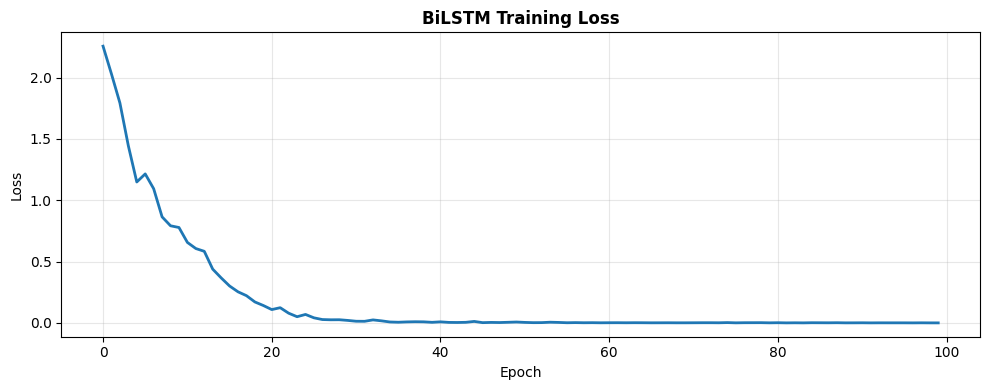

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BiLSTM Training Loss', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Evaluate the BiLSTM model on test data.

In [15]:
def predict_tags(model, token_ids, idx2tag):
    """Predict tags for a sequence."""
    model.eval()
    with torch.no_grad():
        logits = model(token_ids)
        predictions = torch.argmax(logits, dim=-1)
    return predictions

# Evaluate on test data
test_tokens_tensor = test_tokens_tensor.to(device)
bilstm_predictions = predict_tags(bilstm_model, test_tokens_tensor, idx2tag)

print("BiLSTM Predictions on Test Data:")
print("=" * 70)

for i, (tokens, true_tags) in enumerate(test_data):
    pred_tag_ids = bilstm_predictions[i].cpu().numpy()
    pred_tags = [idx2tag[idx] for idx in pred_tag_ids[:len(tokens)]]
    
    print(f"\nExample {i+1}:")
    print(f"{'Token':<15} {'True':<10} {'Predicted':<10} {'Match':<5}")
    print("-" * 45)
    
    for token, true_tag, pred_tag in zip(tokens, true_tags, pred_tags):
        match = "✓" if true_tag == pred_tag else "✗"
        print(f"{token:<15} {true_tag:<10} {pred_tag:<10} {match:<5}")

BiLSTM Predictions on Test Data:

Example 1:
Token           True       Predicted  Match
---------------------------------------------
Bill            B-PER      O          ✗    
Gates           I-PER      O          ✗    
founded         O          O          ✓    
Microsoft       B-ORG      B-ORG      ✓    
.               O          O          ✓    

Example 2:
Token           True       Predicted  Match
---------------------------------------------
Tesla           B-ORG      O          ✗    
is              O          O          ✓    
based           O          O          ✓    
in              O          O          ✓    
Austin          B-LOC      B-LOC      ✓    
.               O          O          ✓    

Example 3:
Token           True       Predicted  Match
---------------------------------------------
The             O          O          ✓    
Olympics        B-MISC     B-LOC      ✗    
were            O          O          ✓    
held            O          O          ✓    
i

**Key Insight**: BiLSTM learns from context but has a limitation - it treats each tag prediction independently. It doesn't enforce constraints like "I-PER must follow B-PER or I-PER". This is where CRF comes in.

## 7. BiLSTM-CRF: Adding Sequence Constraints

### What is a CRF?

A **Conditional Random Field (CRF)** is a sequence model that considers the entire tag sequence when making predictions. Unlike independent classification, CRF:

1. **Enforces tag constraints**: I-PER can't follow B-LOC
2. **Models transitions**: Learns which tag transitions are likely
3. **Global optimization**: Finds the best complete tag sequence (via Viterbi)

**BiLSTM-CRF = BiLSTM + CRF**:
- BiLSTM provides context-aware token representations
- CRF layer ensures valid tag sequences

This is the gold standard for sequence labeling tasks!

Implement a CRF layer from scratch.

In [16]:
class CRF(nn.Module):
    """Conditional Random Field layer for sequence labeling."""
    
    def __init__(self, num_tags):
        super().__init__()
        self.num_tags = num_tags
        
        # Transition parameters: transitions[i, j] = score of transitioning from tag i to tag j
        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))
        
        # Start and end transitions
        self.start_transitions = nn.Parameter(torch.randn(num_tags))
        self.end_transitions = nn.Parameter(torch.randn(num_tags))
    
    def forward(self, emissions, tags, mask=None):
        """
        Compute the negative log-likelihood of a tag sequence.
        
        Args:
            emissions: (batch_size, seq_len, num_tags) - scores from BiLSTM
            tags: (batch_size, seq_len) - true tags
            mask: (batch_size, seq_len) - 1 for real tokens, 0 for padding
        
        Returns:
            loss: negative log-likelihood
        """
        if mask is None:
            mask = torch.ones_like(tags, dtype=torch.float)
        
        # Compute score of gold sequence
        gold_score = self._score_sequence(emissions, tags, mask)
        
        # Compute partition function (sum over all possible sequences)
        partition = self._compute_partition(emissions, mask)
        
        # Negative log-likelihood
        return (partition - gold_score).mean()
    
    def _score_sequence(self, emissions, tags, mask):
        """Compute the score of a given tag sequence."""
        batch_size, seq_len = tags.shape
        score = torch.zeros(batch_size, device=emissions.device)
        
        # Add start transition scores
        score += self.start_transitions[tags[:, 0]]
        
        # Add emission scores and transition scores
        for i in range(seq_len):
            # Emission score for current tag
            current_tags = tags[:, i]
            emission_score = emissions[:, i].gather(1, current_tags.unsqueeze(1)).squeeze(1)
            score += emission_score * mask[:, i]
            
            # Transition score to next tag (if not last position)
            if i < seq_len - 1:
                next_tags = tags[:, i + 1]
                transition_score = self.transitions[current_tags, next_tags]
                score += transition_score * mask[:, i + 1]
        
        # Add end transition scores (for last real token)
        last_tag_indices = mask.sum(1).long() - 1
        last_tags = tags.gather(1, last_tag_indices.unsqueeze(1)).squeeze(1)
        score += self.end_transitions[last_tags]
        
        return score
    
    def _compute_partition(self, emissions, mask):
        """Compute the partition function using forward algorithm."""
        batch_size, seq_len, num_tags = emissions.shape
        
        # Initialize forward variables with start transitions
        alpha = self.start_transitions.unsqueeze(0) + emissions[:, 0]
        
        # Forward pass
        for i in range(1, seq_len):
            # Expand for broadcasting: (batch, num_tags, 1)
            emit_scores = emissions[:, i].unsqueeze(1)
            
            # Transition scores: (num_tags, num_tags)
            trans_scores = self.transitions.unsqueeze(0)
            
            # Compute next alpha: (batch, num_tags, num_tags)
            next_alpha = alpha.unsqueeze(2) + trans_scores + emit_scores
            
            # Log-sum-exp over previous tags: (batch, num_tags)
            next_alpha = torch.logsumexp(next_alpha, dim=1)
            
            # Update alpha with mask
            alpha = next_alpha * mask[:, i].unsqueeze(1) + alpha * (1 - mask[:, i].unsqueeze(1))
        
        # Add end transitions
        alpha = alpha + self.end_transitions.unsqueeze(0)
        
        # Sum over all tags
        return torch.logsumexp(alpha, dim=1)
    
    def decode(self, emissions, mask=None):
        """Find the most likely tag sequence using Viterbi algorithm."""
        if mask is None:
            mask = torch.ones(emissions.shape[:2], dtype=torch.float, device=emissions.device)
        
        batch_size, seq_len, num_tags = emissions.shape
        
        # Initialize
        viterbi = self.start_transitions.unsqueeze(0) + emissions[:, 0]
        backpointers = []
        
        # Forward pass
        for i in range(1, seq_len):
            # Expand for broadcasting
            emit_scores = emissions[:, i].unsqueeze(1)
            trans_scores = self.transitions.unsqueeze(0)
            
            # Compute scores: (batch, num_tags, num_tags)
            next_scores = viterbi.unsqueeze(2) + trans_scores + emit_scores
            
            # Find best previous tag for each current tag
            next_viterbi, next_backpointer = next_scores.max(dim=1)
            
            backpointers.append(next_backpointer)
            viterbi = next_viterbi * mask[:, i].unsqueeze(1) + viterbi * (1 - mask[:, i].unsqueeze(1))
        
        # Add end transitions and find best final tag
        viterbi = viterbi + self.end_transitions.unsqueeze(0)
        best_last_tags = viterbi.argmax(dim=1)
        
        # Backtrack to find best path
        best_paths = [best_last_tags]
        for backpointer in reversed(backpointers):
            best_last_tags = backpointer.gather(1, best_last_tags.unsqueeze(1)).squeeze(1)
            best_paths.insert(0, best_last_tags)
        
        return torch.stack(best_paths, dim=1)

print("CRF layer implemented!")
print("\nKey CRF concepts:")
print("  - Transition matrix: learns valid tag transitions")
print("  - Forward algorithm: computes partition function (all possible sequences)")
print("  - Viterbi algorithm: finds best tag sequence")
print("  - Loss: negative log-likelihood of correct sequence")

CRF layer implemented!

Key CRF concepts:
  - Transition matrix: learns valid tag transitions
  - Forward algorithm: computes partition function (all possible sequences)
  - Viterbi algorithm: finds best tag sequence
  - Loss: negative log-likelihood of correct sequence


Combine BiLSTM with CRF.

In [17]:
class BiLSTM_CRF(nn.Module):
    """BiLSTM-CRF model for NER."""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags, dropout=0.3):
        super().__init__()
        
        # BiLSTM encoder
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.hidden2tag = nn.Linear(hidden_dim * 2, num_tags)
        
        # CRF layer
        self.crf = CRF(num_tags)
    
    def forward(self, input_ids, tags=None):
        """
        Args:
            input_ids: (batch_size, seq_len)
            tags: (batch_size, seq_len), optional for training
        
        Returns:
            if tags provided: loss
            else: predicted tags
        """
        # Get BiLSTM emissions
        mask = (input_ids != 0).float()
        embeds = self.embedding(input_ids)
        embeds = self.dropout(embeds)
        lstm_out, _ = self.lstm(embeds)
        lstm_out = self.dropout(lstm_out)
        emissions = self.hidden2tag(lstm_out)  # (batch, seq_len, num_tags)
        
        if tags is not None:
            # Training: compute loss
            return self.crf(emissions, tags, mask)
        else:
            # Inference: decode best sequence
            return self.crf.decode(emissions, mask)

# Create BiLSTM-CRF model
bilstm_crf_model = BiLSTM_CRF(
    vocab_size=len(vocab),
    embedding_dim=50,
    hidden_dim=64,
    num_tags=len(tag_vocab),
    dropout=0.3
).to(device)

total_params = sum(p.numel() for p in bilstm_crf_model.parameters())
print(f"BiLSTM-CRF Model:")
print(f"  Total parameters: {total_params:,}")
print(f"  BiLSTM parameters: {sum(p.numel() for p in bilstm_crf_model.lstm.parameters()):,}")
print(f"  CRF parameters: {sum(p.numel() for p in bilstm_crf_model.crf.parameters()):,}")

BiLSTM-CRF Model:
  Total parameters: 63,652
  BiLSTM parameters: 59,392
  CRF parameters: 120


Train the BiLSTM-CRF model.

In [18]:
# Training setup
crf_optimizer = torch.optim.Adam(bilstm_crf_model.parameters(), lr=0.01)

# Training loop
bilstm_crf_model.train()
num_epochs = 100
crf_losses = []

for epoch in tqdm(range(num_epochs), desc="Training BiLSTM-CRF"):
    crf_optimizer.zero_grad()
    
    # Forward pass (returns loss when tags are provided)
    loss = bilstm_crf_model(train_tokens_tensor, train_tags_tensor)
    
    # Backward pass
    loss.backward()
    crf_optimizer.step()
    
    crf_losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.4f}")

print("\nTraining complete!")

Training BiLSTM-CRF:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 20/100 - Loss: 2.3430


Epoch 40/100 - Loss: 0.0943


Epoch 60/100 - Loss: 0.0211


Epoch 80/100 - Loss: 0.0129


Epoch 100/100 - Loss: 0.0167

Training complete!


Compare BiLSTM and BiLSTM-CRF training curves.

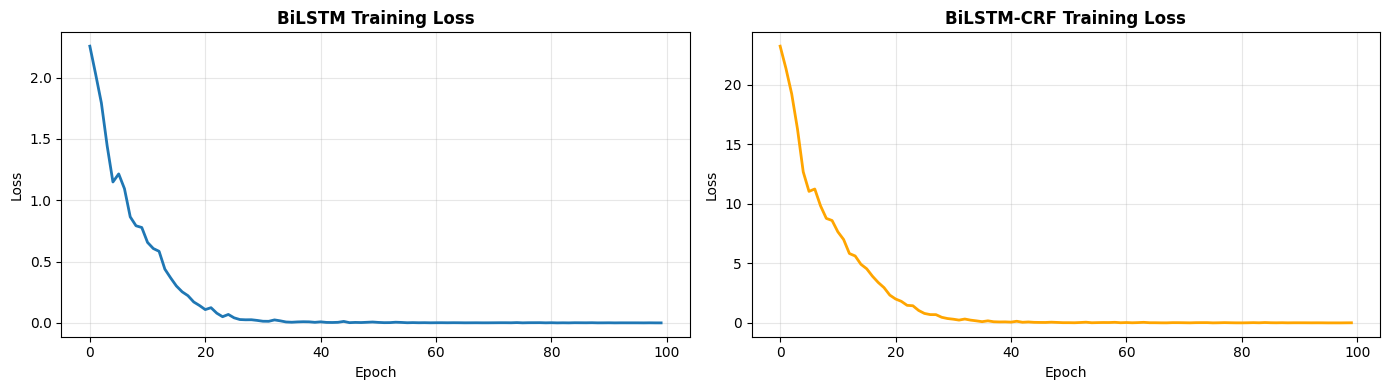

Note: CRF loss is computed differently (negative log-likelihood of sequence)
Cannot directly compare magnitude, but both should decrease over time.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(losses, linewidth=2, label='BiLSTM')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BiLSTM Training Loss', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(crf_losses, linewidth=2, color='orange', label='BiLSTM-CRF')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('BiLSTM-CRF Training Loss', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note: CRF loss is computed differently (negative log-likelihood of sequence)")
print("Cannot directly compare magnitude, but both should decrease over time.")

Evaluate BiLSTM-CRF on test data.

In [20]:
# Get predictions from BiLSTM-CRF
bilstm_crf_model.eval()
with torch.no_grad():
    crf_predictions = bilstm_crf_model(test_tokens_tensor)

print("BiLSTM-CRF Predictions on Test Data:")
print("=" * 70)

for i, (tokens, true_tags) in enumerate(test_data):
    pred_tag_ids = crf_predictions[i].cpu().numpy()
    pred_tags = [idx2tag[idx] for idx in pred_tag_ids[:len(tokens)]]
    
    print(f"\nExample {i+1}:")
    print(f"{'Token':<15} {'True':<10} {'Predicted':<10} {'Match':<5}")
    print("-" * 45)
    
    for token, true_tag, pred_tag in zip(tokens, true_tags, pred_tags):
        match = "✓" if true_tag == pred_tag else "✗"
        print(f"{token:<15} {true_tag:<10} {pred_tag:<10} {match:<5}")

BiLSTM-CRF Predictions on Test Data:

Example 1:
Token           True       Predicted  Match
---------------------------------------------
Bill            B-PER      O          ✗    
Gates           I-PER      O          ✗    
founded         O          O          ✓    
Microsoft       B-ORG      B-ORG      ✓    
.               O          O          ✓    

Example 2:
Token           True       Predicted  Match
---------------------------------------------
Tesla           B-ORG      O          ✗    
is              O          O          ✓    
based           O          O          ✓    
in              O          O          ✓    
Austin          B-LOC      B-LOC      ✓    
.               O          O          ✓    

Example 3:
Token           True       Predicted  Match
---------------------------------------------
The             O          O          ✓    
Olympics        B-MISC     O          ✗    
were            O          O          ✓    
held            O          O          ✓  

**Key Insight**: The CRF layer ensures valid tag sequences. You'll never see impossible transitions like O → I-PER or B-LOC → I-PER. This structural constraint improves performance, especially when training data is limited.

## 8. BERT for Token Classification

### Why BERT for NER?

BERT provides:
1. **Pre-trained contextualized embeddings**: Already knows language structure
2. **Bidirectional context**: Perfect for token classification
3. **Transfer learning**: Fine-tune on your NER data

### Challenge: Subword Tokenization

BERT uses **WordPiece tokenization** which splits words into subwords:
- "playing" → ["play", "##ing"]
- "unhappiness" → ["un", "##hap", "##pi", "##ness"]

**Problem**: Our labels are at the word level, but BERT operates on subwords!

**Solution**: Only predict on the first subword of each word, ignore the rest.

Install and import HuggingFace transformers for BERT.

In [21]:
try:
    from transformers import BertTokenizerFast, BertForTokenClassification
    print("Transformers library loaded successfully!")
except ImportError:
    print("Installing transformers library...")
    import sys
    !{sys.executable} -m pip install transformers -q
    from transformers import BertTokenizerFast, BertForTokenClassification
    print("Transformers library installed and loaded!")

Transformers library loaded successfully!


Create a BERT tokenizer and demonstrate subword alignment.

In [22]:
# Load BERT tokenizer (Fast version for word_ids support)
bert_tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

# Demonstrate subword tokenization
example_tokens = ["playing", "basketball", "professionally"]
example_tags = ["O", "O", "O"]

print("Subword Tokenization Example:")
print("=" * 60)
print(f"\n{'Word':<20} {'Subwords':<30} {'Tag':<10}")
print("-" * 60)

for word, tag in zip(example_tokens, example_tags):
    # Tokenize word (without special tokens)
    subwords = bert_tokenizer.tokenize(word)
    subword_str = str(subwords)
    print(f"{word:<20} {subword_str:<30} {tag:<10}")

print("\nKey insight: We assign the tag to the FIRST subword only.")
print("Subsequent subwords get a special -100 label (ignored in loss).")

Subword Tokenization Example:

Word                 Subwords                       Tag       
------------------------------------------------------------
playing              ['playing']                    O         
basketball           ['basketball']                 O         
professionally       ['professionally']             O         

Key insight: We assign the tag to the FIRST subword only.
Subsequent subwords get a special -100 label (ignored in loss).


Create a function to align word-level labels with subword tokens.

In [23]:
def align_labels_with_tokens(tokens, tags, tokenizer, tag_vocab):
    """
    Align word-level tags with subword tokens.
    
    Args:
        tokens: List of words
        tags: List of BIO tags (same length as tokens)
        tokenizer: BERT tokenizer
        tag_vocab: Tag to index mapping
    
    Returns:
        input_ids: Subword token IDs
        aligned_labels: Labels for each subword (-100 for non-first subwords)
    """
    # Tokenize with special tokens
    encoding = tokenizer(
        tokens,
        is_split_into_words=True,
        padding='max_length',
        max_length=32,
        truncation=True,
        return_tensors='pt'
    )
    
    # Get word IDs to align labels
    word_ids = encoding.word_ids(batch_index=0)
    
    # Align labels
    aligned_labels = []
    previous_word_idx = None
    
    for word_idx in word_ids:
        if word_idx is None:
            # Special tokens ([CLS], [SEP], [PAD])
            aligned_labels.append(-100)
        elif word_idx != previous_word_idx:
            # First subword of a word - use the tag
            aligned_labels.append(tag_vocab[tags[word_idx]])
        else:
            # Continuation subword - ignore in loss
            aligned_labels.append(-100)
        
        previous_word_idx = word_idx
    
    return encoding['input_ids'][0], torch.tensor(aligned_labels)

# Test alignment
sample_tokens, sample_tags = train_data[0]
aligned_ids, aligned_labels = align_labels_with_tokens(sample_tokens, sample_tags, bert_tokenizer, tag_vocab)

print("Label Alignment Example:")
print("=" * 70)
print(f"\nOriginal words: {sample_tokens}")
print(f"Original tags: {sample_tags}")
print(f"\nSubword tokens: {bert_tokenizer.convert_ids_to_tokens(aligned_ids)}")
print(f"Aligned labels: {aligned_labels.tolist()}")
print(f"\nNote: -100 means 'ignore in loss calculation'")

Label Alignment Example:

Original words: ['Barack', 'Obama', 'was', 'born', 'in', 'Hawaii', '.']
Original tags: ['B-PER', 'I-PER', 'O', 'O', 'O', 'B-LOC', 'O']

Subword tokens: ['[CLS]', 'barack', 'obama', 'was', 'born', 'in', 'hawaii', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Aligned labels: [-100, 9, 1, 6, 6, 6, 7, 6, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]

Note: -100 means 'ignore in loss calculation'


Prepare BERT-compatible dataset.

In [24]:
# Prepare all training data for BERT
bert_train_inputs = []
bert_train_labels = []

for tokens, tags in train_data:
    input_ids, labels = align_labels_with_tokens(tokens, tags, bert_tokenizer, tag_vocab)
    bert_train_inputs.append(input_ids)
    bert_train_labels.append(labels)

bert_train_inputs = torch.stack(bert_train_inputs)
bert_train_labels = torch.stack(bert_train_labels)

# Prepare test data
bert_test_inputs = []
bert_test_labels = []

for tokens, tags in test_data:
    input_ids, labels = align_labels_with_tokens(tokens, tags, bert_tokenizer, tag_vocab)
    bert_test_inputs.append(input_ids)
    bert_test_labels.append(labels)

bert_test_inputs = torch.stack(bert_test_inputs)
bert_test_labels = torch.stack(bert_test_labels)

print(f"BERT Training data shape: {bert_train_inputs.shape}")
print(f"BERT Training labels shape: {bert_train_labels.shape}")
print(f"BERT Test data shape: {bert_test_inputs.shape}")

BERT Training data shape: torch.Size([12, 32])
BERT Training labels shape: torch.Size([12, 32])
BERT Test data shape: torch.Size([3, 32])


Load a pre-trained BERT model for token classification.

In [25]:
# Load BERT for token classification
bert_model = BertForTokenClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(tag_vocab),
    ignore_mismatched_sizes=True
).to(device)

# Count parameters
total_params = sum(p.numel() for p in bert_model.parameters())
trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)

print(f"BERT Model for Token Classification:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Number of labels: {len(tag_vocab)}")

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT Model for Token Classification:
  Total parameters: 108,899,338
  Trainable parameters: 108,899,338
  Number of labels: 10


Fine-tune BERT on the NER task.

In [26]:
# Training setup
bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=5e-5)

# Move data to device
bert_train_inputs = bert_train_inputs.to(device)
bert_train_labels = bert_train_labels.to(device)

# Training loop
bert_model.train()
num_epochs = 20  # Fewer epochs since BERT is pre-trained
bert_losses = []

for epoch in tqdm(range(num_epochs), desc="Fine-tuning BERT"):
    bert_optimizer.zero_grad()
    
    # Forward pass
    outputs = bert_model(bert_train_inputs, labels=bert_train_labels)
    loss = outputs.loss
    
    # Backward pass
    loss.backward()
    bert_optimizer.step()
    
    bert_losses.append(loss.item())
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.4f}")

print("\nFine-tuning complete!")

Fine-tuning BERT:   0%|          | 0/20 [00:00<?, ?it/s]

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Epoch 5/20 - Loss: 0.9460


Epoch 10/20 - Loss: 0.4186


Epoch 15/20 - Loss: 0.1833


Epoch 20/20 - Loss: 0.0767

Fine-tuning complete!


Visualize BERT fine-tuning progress.

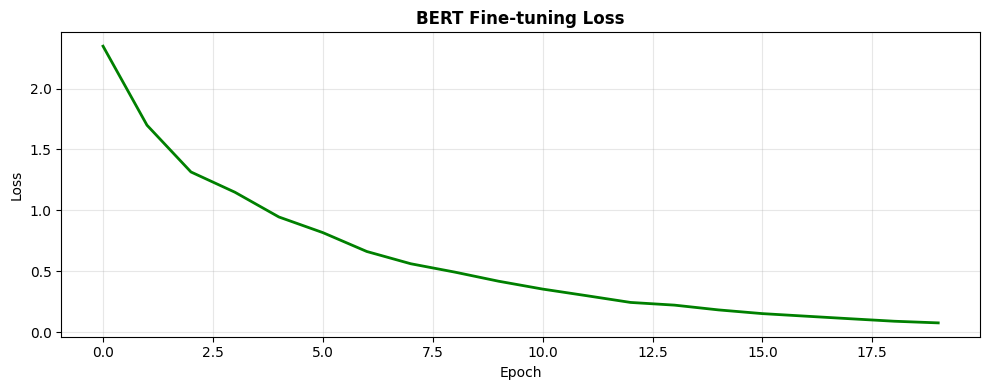

Note: BERT converges faster because it starts with pre-trained weights!


In [27]:
plt.figure(figsize=(10, 4))
plt.plot(bert_losses, linewidth=2, color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BERT Fine-tuning Loss', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Note: BERT converges faster because it starts with pre-trained weights!")

Evaluate BERT on test data.

In [28]:
# Evaluate BERT
bert_model.eval()
bert_test_inputs = bert_test_inputs.to(device)

with torch.no_grad():
    outputs = bert_model(bert_test_inputs)
    bert_predictions = torch.argmax(outputs.logits, dim=-1)

print("BERT Predictions on Test Data:")
print("=" * 70)

for i, (tokens, true_tags) in enumerate(test_data):
    print(f"\nExample {i+1}:")
    print(f"{'Token':<15} {'True':<10} {'Predicted':<10} {'Match':<5}")
    print("-" * 45)
    
    # Get predictions for first subword of each word
    encoding = bert_tokenizer(
        tokens,
        is_split_into_words=True,
        padding='max_length',
        max_length=32,
        truncation=True
    )
    word_ids = encoding.word_ids()
    
    # Extract predictions for each word
    word_predictions = []
    previous_word_idx = None
    
    for j, word_idx in enumerate(word_ids):
        if word_idx is not None and word_idx != previous_word_idx:
            pred_tag_id = bert_predictions[i, j].item()
            word_predictions.append(idx2tag[pred_tag_id])
        previous_word_idx = word_idx
    
    # Display
    for token, true_tag, pred_tag in zip(tokens, true_tags, word_predictions):
        match = "✓" if true_tag == pred_tag else "✗"
        print(f"{token:<15} {true_tag:<10} {pred_tag:<10} {match:<5}")

BERT Predictions on Test Data:

Example 1:
Token           True       Predicted  Match
---------------------------------------------
Bill            B-PER      B-PER      ✓    
Gates           I-PER      I-PER      ✓    
founded         O          O          ✓    
Microsoft       B-ORG      B-ORG      ✓    
.               O          O          ✓    

Example 2:
Token           True       Predicted  Match
---------------------------------------------
Tesla           B-ORG      B-ORG      ✓    
is              O          O          ✓    
based           O          O          ✓    
in              O          O          ✓    
Austin          B-LOC      B-LOC      ✓    
.               O          O          ✓    

Example 3:
Token           True       Predicted  Match
---------------------------------------------
The             O          O          ✓    
Olympics        B-MISC     I-MISC     ✗    
were            O          O          ✓    
held            O          O          ✓    
in 

**Key Insight**: BERT's pre-trained knowledge helps it generalize better, especially on limited training data. The subword tokenization requires careful label alignment, but enables handling of out-of-vocabulary words.

## 9. Proper NER Evaluation: Entity-Level Metrics

### Why Token Accuracy is Insufficient

Consider this prediction:
```
True:      [B-PER, I-PER, O]
Predicted: [B-PER, O,     O]
```

Token accuracy: 2/3 = 66.7%
Entity accuracy: 0/1 = 0% (entity not fully recognized)

**Entity-level evaluation** considers an entity correct only if:
1. **Exact boundary match**: All tokens of the entity are correctly identified
2. **Correct type**: The entity type matches (PER, ORG, LOC, etc.)

We use **span-based F1 score** as the standard NER metric.

Implement entity-level evaluation.

In [29]:
def extract_entities(tokens, tags):
    """
    Extract entities from BIO-tagged sequence.
    
    Returns:
        List of (start, end, entity_type) tuples
    """
    entities = []
    current_entity = None
    
    for i, (token, tag) in enumerate(zip(tokens, tags)):
        if tag.startswith('B-'):
            # Start of new entity
            if current_entity is not None:
                entities.append(current_entity)
            entity_type = tag[2:]
            current_entity = (i, i + 1, entity_type)
        elif tag.startswith('I-') and current_entity is not None:
            # Continuation of entity
            entity_type = tag[2:]
            if entity_type == current_entity[2]:
                current_entity = (current_entity[0], i + 1, entity_type)
            else:
                # Type mismatch - treat as new entity
                entities.append(current_entity)
                current_entity = (i, i + 1, entity_type)
        else:
            # O tag - end current entity
            if current_entity is not None:
                entities.append(current_entity)
            current_entity = None
    
    if current_entity is not None:
        entities.append(current_entity)
    
    return set(entities)

def compute_entity_f1(true_tags_list, pred_tags_list):
    """
    Compute entity-level precision, recall, and F1.
    """
    total_true = 0
    total_pred = 0
    total_correct = 0
    
    for true_tags, pred_tags in zip(true_tags_list, pred_tags_list):
        # Extract entities (without tokens, just use indices)
        true_entities = extract_entities(range(len(true_tags)), true_tags)
        pred_entities = extract_entities(range(len(pred_tags)), pred_tags)
        
        total_true += len(true_entities)
        total_pred += len(pred_entities)
        total_correct += len(true_entities & pred_entities)
    
    precision = total_correct / total_pred if total_pred > 0 else 0.0
    recall = total_correct / total_true if total_true > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return precision, recall, f1

# Test entity extraction
sample_tokens = ["Barack", "Obama", "visited", "Hawaii"]
sample_tags = ["B-PER", "I-PER", "O", "B-LOC"]
entities = extract_entities(sample_tokens, sample_tags)

print("Entity Extraction Example:")
print(f"Tokens: {sample_tokens}")
print(f"Tags: {sample_tags}")
print(f"\nExtracted entities: {entities}")
print("Format: (start_index, end_index, entity_type)")

Entity Extraction Example:
Tokens: ['Barack', 'Obama', 'visited', 'Hawaii']
Tags: ['B-PER', 'I-PER', 'O', 'B-LOC']

Extracted entities: {(3, 4, 'LOC'), (0, 2, 'PER')}
Format: (start_index, end_index, entity_type)


Compare all models using entity-level F1.

In [30]:
# Collect predictions from all models
all_true_tags = [tags for _, tags in test_data]

# BiLSTM predictions
bilstm_pred_tags = []
bilstm_model.eval()
with torch.no_grad():
    for i in range(len(test_data)):
        logits = bilstm_model(test_tokens_tensor[i:i+1])
        preds = torch.argmax(logits, dim=-1)[0].cpu().numpy()
        pred_tags = [idx2tag[idx] for idx in preds[:len(test_data[i][0])]]
        bilstm_pred_tags.append(pred_tags)

# BiLSTM-CRF predictions
crf_pred_tags = []
for i in range(len(test_data)):
    pred_tag_ids = crf_predictions[i].cpu().numpy()
    pred_tags = [idx2tag[idx] for idx in pred_tag_ids[:len(test_data[i][0])]]
    crf_pred_tags.append(pred_tags)

# BERT predictions (already computed)
bert_pred_tags = []
for i, (tokens, _) in enumerate(test_data):
    encoding = bert_tokenizer(
        tokens,
        is_split_into_words=True,
        padding='max_length',
        max_length=32,
        truncation=True
    )
    word_ids = encoding.word_ids()
    
    word_predictions = []
    previous_word_idx = None
    
    for j, word_idx in enumerate(word_ids):
        if word_idx is not None and word_idx != previous_word_idx:
            pred_tag_id = bert_predictions[i, j].item()
            word_predictions.append(idx2tag[pred_tag_id])
        previous_word_idx = word_idx
    
    bert_pred_tags.append(word_predictions)

# Compute entity-level F1 for all models
print("Entity-Level Evaluation Results:")
print("=" * 70)

models = [
    ("Rule-based", rule_predictions),
    ("BiLSTM", bilstm_pred_tags),
    ("BiLSTM-CRF", crf_pred_tags),
    ("BERT", bert_pred_tags),
]

for model_name, predictions in models:
    precision, recall, f1 = compute_entity_f1(all_true_tags, predictions)
    print(f"\n{model_name}:")
    print(f"  Precision: {precision:.2%}")
    print(f"  Recall:    {recall:.2%}")
    print(f"  F1 Score:  {f1:.2%}")

Entity-Level Evaluation Results:

Rule-based:
  Precision: 100.00%
  Recall:    100.00%
  F1 Score:  100.00%

BiLSTM:
  Precision: 75.00%
  Recall:    50.00%
  F1 Score:  60.00%

BiLSTM-CRF:
  Precision: 100.00%
  Recall:    50.00%
  F1 Score:  66.67%

BERT:
  Precision: 100.00%
  Recall:    83.33%
  F1 Score:  90.91%


Visualize model comparison.

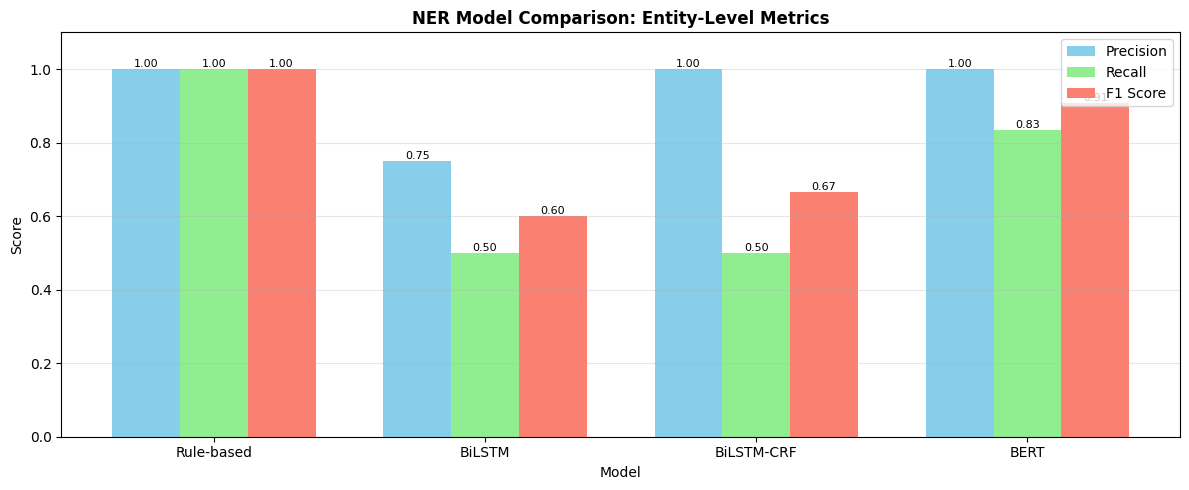

In [31]:
# Compute metrics for plotting
model_names = []
precisions = []
recalls = []
f1_scores = []

for model_name, predictions in models:
    precision, recall, f1 = compute_entity_f1(all_true_tags, predictions)
    model_names.append(model_name)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

# Plot comparison
x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width, precisions, width, label='Precision', color='skyblue')
bars2 = ax.bar(x, recalls, width, label='Recall', color='lightgreen')
bars3 = ax.bar(x + width, f1_scores, width, label='F1 Score', color='salmon')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('NER Model Comparison: Entity-Level Metrics', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

**Key Insight**: Entity-level F1 is the standard NER metric because:
- Partial matches don't count (must get entire entity)
- Type must be correct
- Balances precision (don't over-predict) and recall (don't miss entities)

This is much more informative than token-level accuracy!

## 10. Practical Considerations

### 10.1 Handling Nested Entities

Some texts have nested entities:
- "[University of [California]LOC]ORG"
- "[Bank of [America]LOC]ORG"

Standard BIO tagging can't handle this. Solutions:
1. **Flatten to outermost entity** (most common)
2. **Use BIOES scheme** (Beginning, Inside, Outside, End, Single)
3. **Multi-task learning** with separate models for each nesting level
4. **Span-based models** (predict all possible spans)

Demonstrate the nested entity problem.

In [32]:
print("Nested Entity Example:")
print("=" * 60)
print("\nText: 'University of California'")
print("\nNested structure:")
print("  [University of [California]LOC]ORG")
print("\nProblem with BIO tagging:")
print("  Can only assign ONE tag per token")
print("  Must choose: California = LOC or part of ORG?")
print("\nCommon solution: Flatten to outermost")
print("  University -> B-ORG")
print("  of -> I-ORG")
print("  California -> I-ORG")
print("\nNote: This loses information about the nested location!")

Nested Entity Example:

Text: 'University of California'

Nested structure:
  [University of [California]LOC]ORG

Problem with BIO tagging:
  Can only assign ONE tag per token
  Must choose: California = LOC or part of ORG?

Common solution: Flatten to outermost
  University -> B-ORG
  of -> I-ORG
  California -> I-ORG

Note: This loses information about the nested location!


### 10.2 Few-Shot and Zero-Shot NER

What if you don't have labeled training data?

**Few-Shot NER**:
- Provide a few examples in the prompt
- Use metric learning (prototypical networks)
- Fine-tune large language models on minimal examples

**Zero-Shot NER**:
- Use instruction-tuned LLMs (GPT, Claude)
- Prompt: "Identify person names, organizations, and locations in: ..."
- No training required, but less reliable than fine-tuned models

Simulate a zero-shot NER prompt.

In [33]:
def create_zero_shot_ner_prompt(text):
    """Create a zero-shot NER prompt for an LLM."""
    prompt = f"""Extract named entities from the following text and classify them as PERSON, ORGANIZATION, LOCATION, or MISCELLANEOUS.

Text: {text}

Return the entities in this format:
- Entity: [entity text] | Type: [entity type]

Entities:"""
    return prompt

# Example
sample_text = "Elon Musk founded SpaceX in California."
prompt = create_zero_shot_ner_prompt(sample_text)

print("Zero-Shot NER Prompt Example:")
print("=" * 60)
print(prompt)
print("\nExpected response:")
print("- Entity: Elon Musk | Type: PERSON")
print("- Entity: SpaceX | Type: ORGANIZATION")
print("- Entity: California | Type: LOCATION")

Zero-Shot NER Prompt Example:
Extract named entities from the following text and classify them as PERSON, ORGANIZATION, LOCATION, or MISCELLANEOUS.

Text: Elon Musk founded SpaceX in California.

Return the entities in this format:
- Entity: [entity text] | Type: [entity type]

Entities:

Expected response:
- Entity: Elon Musk | Type: PERSON
- Entity: SpaceX | Type: ORGANIZATION
- Entity: California | Type: LOCATION


### 10.3 Active Learning for Efficient Annotation

Labeling data for NER is expensive. **Active learning** helps prioritize which examples to label:

1. **Uncertainty sampling**: Label examples where the model is least confident
2. **Diversity sampling**: Label examples that are different from existing data
3. **Query-by-committee**: Train multiple models, label examples where they disagree

This can reduce annotation cost by 50-90% while maintaining performance!

Demonstrate uncertainty-based active learning.

In [34]:
def compute_prediction_uncertainty(model, input_ids):
    """Compute uncertainty for active learning."""
    model.eval()
    with torch.no_grad():
        logits = model(input_ids.to(device))
        probs = F.softmax(logits, dim=-1)
        
        # Use entropy as uncertainty measure
        entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=-1)
        
        # Average entropy across tokens
        avg_entropy = entropy.mean(dim=-1)
    
    return avg_entropy.cpu().numpy()

# Compute uncertainty for test examples
uncertainties = compute_prediction_uncertainty(bilstm_model, test_tokens_tensor)

print("Active Learning: Uncertainty-Based Sampling")
print("=" * 60)
print("\nExamples ranked by model uncertainty (high = should label first):")
print()

# Sort by uncertainty
sorted_indices = np.argsort(uncertainties)[::-1]

for rank, idx in enumerate(sorted_indices, 1):
    tokens, _ = test_data[idx]
    text = ' '.join(tokens)
    uncertainty = uncertainties[idx]
    print(f"{rank}. Uncertainty: {uncertainty:.3f} | Text: {text}")

print("\nIn active learning, you would:")
print("1. Label the most uncertain examples first")
print("2. Retrain the model")
print("3. Repeat until performance is good enough")
print("\nThis minimizes annotation cost!")

Active Learning: Uncertainty-Based Sampling

Examples ranked by model uncertainty (high = should label first):

1. Uncertainty: 0.426 | Text: The Olympics were held in Tokyo .
2. Uncertainty: 0.415 | Text: Tesla is based in Austin .
3. Uncertainty: 0.353 | Text: Bill Gates founded Microsoft .

In active learning, you would:
1. Label the most uncertain examples first
2. Retrain the model
3. Repeat until performance is good enough

This minimizes annotation cost!


## 11. Key Takeaways

### What We Learned:

1. **BIO Tagging Scheme**: Essential for representing multi-word entities and distinguishing consecutive entities of the same type
   - B-XXX: Beginning of entity
   - I-XXX: Inside entity
   - O: Outside any entity

2. **Model Progression**:
   - **Rule-based**: Fast, interpretable, but doesn't generalize
   - **BiLSTM**: Learns from context bidirectionally
   - **BiLSTM-CRF**: Adds sequence constraints (best for structured prediction)
   - **BERT**: Pre-trained, best performance with limited data

3. **CRF Layer**: Enforces valid tag sequences and models transition probabilities
   - Forward algorithm: Computes partition function
   - Viterbi algorithm: Finds best tag sequence
   - Learns which transitions are valid (e.g., I-PER can't follow B-LOC)

4. **BERT Challenges**: Subword tokenization requires careful label alignment
   - Only predict on first subword of each word
   - Use -100 label to ignore other subwords in loss

5. **Evaluation**: Entity-level F1 is the gold standard
   - Token accuracy is misleading
   - Must match exact boundaries AND type
   - Precision/Recall/F1 at entity level

6. **Practical Considerations**:
   - Nested entities require special handling
   - Zero-shot NER possible with LLMs
   - Active learning reduces annotation cost

### Why NER Matters:

- **Foundation for information extraction**: Identifies key entities in text
- **Building block for QA systems**: Knows what things are mentioned
- **Knowledge graph construction**: Populates databases with entities
- **Document understanding**: Extracts structured information from unstructured text

### Architecture Insights:

**BiLSTM-CRF** is the classic approach:
- BiLSTM: Context-aware token representations
- CRF: Valid sequence constraints
- Works well with moderate data

**BERT** is state-of-the-art:
- Pre-trained on massive corpora
- Excellent with limited task-specific data
- Handles out-of-vocabulary words via subwords

### Common Pitfalls:

- Using token accuracy instead of entity-level F1
- Forgetting to align labels with subword tokens in BERT
- Not handling class imbalance (most tokens are O)
- Ignoring transition constraints in label sequences

## 12. Further Exploration

To deepen your understanding of NER:

1. **Try different datasets**: CoNLL-2003, OntoNotes, WikiNER
2. **Experiment with BIOES scheme**: Beginning, Inside, Outside, End, Single
3. **Add character-level features**: Capture morphology and spelling patterns
4. **Use ELMo or other contextual embeddings**: Compare with BERT
5. **Implement span-based NER**: Alternative to BIO tagging
6. **Try cross-lingual NER**: Transfer from high-resource to low-resource languages
7. **Explore domain adaptation**: Medical NER, legal NER, etc.

### Resources:

- **Papers**:
  - "Bidirectional LSTM-CRF Models for Sequence Tagging" (Huang et al., 2015)
  - "Named Entity Recognition with Bidirectional LSTM-CNNs" (Chiu & Nichols, 2016)
  - "BERT for Named Entity Recognition" (Devlin et al., 2018)

- **Datasets**:
  - CoNLL-2003: Standard benchmark (English news)
  - OntoNotes 5.0: Larger, more entity types
  - WikiNER: Automatically annotated from Wikipedia

- **Libraries**:
  - spaCy: Production-ready NER
  - Flair: Easy-to-use sequence labeling
  - HuggingFace Transformers: BERT and variants

### Advanced Topics:

1. **Few-shot NER**: Learn from minimal examples
2. **Nested NER**: Handle overlapping entities
3. **Distantly supervised NER**: Use knowledge bases for weak supervision
4. **Multi-task learning**: Joint NER and relation extraction
5. **Adversarial training**: Improve robustness to typos and variations